# Column Transformation

In [1]:
# A Column Transformer is a tool from Scikit-learn that allows you to apply different transformations to different columns of your dataset

In [2]:
# It helps you preprocess multiple columns in different ways at the same time.

In [8]:
# In real datasets:

#     Some columns are numeric → need scaling
#     Some are categorical → need encoding

#   ColumnTransformer lets you handle both together in one pipeline.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Module Loaded")

Module Loaded


In [9]:
data = {
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 70000],
    'City': ['Delhi', 'Mumbai', 'Delhi']
}

In [10]:
data

{'Age': [25, 30, 35],
 'Salary': [50000, 60000, 70000],
 'City': ['Delhi', 'Mumbai', 'Delhi']}

In [11]:
df= pd.DataFrame(data)

In [12]:
df

,Age,Salary,City
0,25,50000,Delhi
1,30,60000,Mumbai
2,35,70000,Delhi


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [14]:
# Define transformations
transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['Age', 'Salary']),   # numeric columns
        ('cat', OneHotEncoder(), ['City'])              # categorical column
    ]
)

In [15]:
# Apply transformation
transformed_data = transformer.fit_transform(df)

In [16]:
transformed_data

array([[-1.22474487, -1.22474487,  1.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ],
       [ 1.22474487,  1.22474487,  1.        ,  0.        ]])

# What happens here?

    Age & Salary → scaled using StandardScaler
    City → converted into numbers using OneHotEncoder

    Output becomes a numeric matrix ready for ML models.

In [17]:
df = pd.read_csv(r"C:\Users\u\Desktop\Project\python-data-science-mastery\EDA and Feature Engineering\Dataset\covid_toy.csv")

In [18]:
df

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [20]:
df

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


| Tool           | Use Case                      |
| -------------- | ----------------------------- |
| SimpleImputer  | Fill missing values           |
| OneHotEncoder  | Categorical → binary columns  |
| OrdinalEncoder | Categorical → ordered numbers |


In [21]:
# SimpleImputer → “Fill missing data”
# OneHotEncoder → “Convert categories to 0/1”
# OrdinalEncoder → “Convert categories to ranks”

# SimpleImputer

In [22]:
# What it does:

#     Handles missing values (NaN) in your dataset.
    
#     Real-world data often has missing values, so we fill them using:

#     mean
#     median
#     most frequent value

In [23]:
from sklearn.impute import SimpleImputer

data = [[1], [2], [np.nan], [4]]

imputer = SimpleImputer(strategy='mean')
result = imputer.fit_transform(data)


In [24]:
data

[[1], [2], [nan], [4]]

In [25]:
result

array([[1.        ],
       [2.        ],
       [2.33333333],
       [4.        ]])

# OneHotEncoder

 <!-- What it does:

    Converts categorical data → numerical format (for ML models)
    
    It creates binary columns (0/1) -->

In [26]:
# What it does:

#     Converts categorical data → numerical format (for ML models)
    
#      It creates binary columns (0/1)

In [27]:
from sklearn.preprocessing import OneHotEncoder

data = [['Red'], ['Blue'], ['Green']]

encoder = OneHotEncoder()
result = encoder.fit_transform(data).toarray()

In [28]:
result

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

# OrdinalEncoder

In [29]:
# What it does:

#     Converts categorical data into ordered numbers
    
#     Used when categories have a natural order

In [30]:
data = [['Low'], ['Medium'], ['High']]

encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
result = encoder.fit_transform(data)

In [31]:
result

array([[0.],
       [1.],
       [2.]])

In [32]:
df

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No
...,...,...,...,...,...,...
95,12,Female,104.0,Mild,Bangalore,No
96,51,Female,101.0,Strong,Kolkata,Yes
97,20,Female,101.0,Mild,Bangalore,No
98,5,Female,98.0,Strong,Mumbai,No


In [33]:
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        100 non-null    int64  
 1   gender     100 non-null    object 
 2   fever      90 non-null     float64
 3   cough      100 non-null    object 
 4   city       100 non-null    object 
 5   has_covid  100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [40]:
df['fever'].value_counts()

fever
101.0    17
98.0     17
104.0    14
100.0    13
99.0     10
102.0    10
103.0     9
Name: count, dtype: int64

In [41]:
df['city'].value_counts()

city
Kolkata      32
Bangalore    30
Delhi        22
Mumbai       16
Name: count, dtype: int64

In [43]:
df['cough'].value_counts()

cough
Mild      62
Strong    38
Name: count, dtype: int64

In [44]:
df.isnull().sum()

age           0
gender        0
fever        10
cough         0
city          0
has_covid     0
dtype: int64

In [46]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['has_covid']),df['has_covid'],test_size=0.2)

In [47]:
X_train

,age,gender,fever,cough,city
7,20,Female,NaN,Strong,Mumbai
80,14,Female,99.0,Mild,Mumbai
34,74,Male,102.0,Mild,Mumbai
39,50,Female,103.0,Mild,Kolkata
26,19,Female,100.0,Mild,Kolkata
...,...,...,...,...,...
4,65,Female,101.0,Mild,Mumbai
44,20,Male,102.0,Strong,Delhi
61,81,Female,98.0,Strong,Mumbai
71,75,Female,104.0,Strong,Delhi


In [48]:
y_train

7     Yes
80    Yes
34    Yes
39     No
26    Yes
     ... 
4      No
44     No
61     No
71     No
13    Yes
Name: has_covid, Length: 80, dtype: object

In [49]:
si = SimpleImputer()

In [51]:
si

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [53]:
X_train_fever = si.fit_transform(X_train[['fever']])

In [54]:
X_train_fever

array([[101.],
       [ 99.],
       [102.],
       [103.],
       [100.],
       [104.],
       [101.],
       [ 98.],
       [104.],
       [104.],
       [ 98.],
       [100.],
       [101.],
       [ 99.],
       [104.],
       [100.],
       [104.],
       [101.],
       [101.],
       [ 98.],
       [104.],
       [101.],
       [101.],
       [103.],
       [101.],
       [101.],
       [103.],
       [ 99.],
       [100.],
       [104.],
       [100.],
       [100.],
       [101.],
       [100.],
       [101.],
       [103.],
       [ 99.],
       [104.],
       [103.],
       [ 98.],
       [100.],
       [101.],
       [ 98.],
       [104.],
       [104.],
       [100.],
       [102.],
       [ 98.],
       [101.],
       [103.],
       [ 98.],
       [ 98.],
       [ 99.],
       [101.],
       [101.],
       [102.],
       [102.],
       [102.],
       [103.],
       [ 98.],
       [104.],
       [ 99.],
       [ 98.],
       [101.],
       [103.],
       [101.],
       [ 9

In [55]:
X_test_fever = si.fit_transform(X_test[['fever']])

In [56]:
X_test_fever

array([[103.        ],
       [101.        ],
       [100.17647059],
       [100.17647059],
       [ 99.        ],
       [101.        ],
       [102.        ],
       [ 98.        ],
       [100.17647059],
       [100.        ],
       [104.        ],
       [ 98.        ],
       [ 98.        ],
       [100.        ],
       [100.        ],
       [ 98.        ],
       [ 99.        ],
       [ 99.        ],
       [101.        ],
       [102.        ]])

In [57]:
X_train.shape

(80, 5)

In [58]:
X_test_fever.shape

(20, 1)

In [59]:
X_train_fever.shape

(80, 1)

In [60]:
X_test.shape

(20, 5)

In [61]:
oe = OrdinalEncoder(categories=[['Mild','Strong']])

In [62]:
oe

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Mild', 'Strong']]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [63]:
X_train_cough = oe.fit_transform(X_train[['cough']])

X_test_cough = oe.fit_transform(X_test[['cough']])


In [64]:
X_train_cough.shape

(80, 1)

In [65]:
X_test_cough.shape

(20, 1)

In [78]:
ohe = OneHotEncoder(drop='first',sparse_output=False)

X_train_gender_city = ohe.fit_transform(X_train[['gender','city']])

X_test_gender_city = ohe.fit_transform(X_test[['gender','city']])

X_train_gender_city.shape

(80, 4)

In [79]:
X_train_gender_city.shape

(80, 4)

In [80]:
# Extracting Age
X_train_age = X_train.drop(columns=['gender','fever','cough','city']).values

# also the test data
X_test_age = X_test.drop(columns=['gender','fever','cough','city']).values

X_train_age.shape

(80, 1)

In [81]:
print(X_train_age.shape)
print(X_train_fever.shape)
print(X_train_gender_city.shape)
print(X_train_cough.shape)

(80, 1)
(80, 1)
(80, 4)
(80, 1)


In [82]:
print(type(X_train_age))
print(type(X_train_fever))
print(type(X_train_gender_city))
print(type(X_train_cough))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [83]:
X_train_transformed = np.concatenate((X_train_age,X_train_fever,X_train_gender_city,X_train_cough),axis=1)

X_test_transformed = np.concatenate((X_test_age,X_test_fever,X_test_gender_city,X_test_cough),axis=1)

X_train_transformed.shape

(80, 7)

In [84]:
X_train_transformed

array([[ 20., 101.,   0.,   0.,   0.,   1.,   1.],
       [ 14.,  99.,   0.,   0.,   0.,   1.,   0.],
       [ 74., 102.,   1.,   0.,   0.,   1.,   0.],
       [ 50., 103.,   0.,   0.,   1.,   0.,   0.],
       [ 19., 100.,   0.,   0.,   1.,   0.,   0.],
       [ 42., 104.,   1.,   0.,   0.,   1.,   0.],
       [ 38., 101.,   1.,   1.,   0.,   0.,   0.],
       [  5.,  98.,   0.,   0.,   0.,   1.,   1.],
       [ 25., 104.,   1.,   0.,   0.,   0.,   0.],
       [ 44., 104.,   1.,   0.,   0.,   1.,   0.],
       [ 80.,  98.,   0.,   1.,   0.,   0.,   0.],
       [ 10., 100.,   1.,   0.,   0.,   0.,   0.],
       [  8., 101.,   0.,   0.,   1.,   0.,   0.],
       [ 49.,  99.,   0.,   0.,   0.,   0.,   1.],
       [ 56., 104.,   0.,   0.,   0.,   0.,   1.],
       [ 47., 100.,   0.,   0.,   0.,   0.,   1.],
       [ 51., 104.,   1.,   0.,   0.,   0.,   0.],
       [ 51., 101.,   0.,   0.,   1.,   0.,   1.],
       [ 42., 101.,   1.,   1.,   0.,   0.,   0.],
       [ 26.,  98.,   0.,   0.,

In [85]:
X_test_transformed

array([[ 16.        , 103.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ],
       [ 83.        , 101.        ,   0.        ,   0.        ,
          1.        ,   0.        ,   0.        ],
       [ 82.        , 100.17647059,   1.        ,   0.        ,
          1.        ,   0.        ,   0.        ],
       [ 79.        , 100.17647059,   1.        ,   0.        ,
          1.        ,   0.        ,   1.        ],
       [ 66.        ,  99.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   1.        ],
       [ 64.        , 101.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   0.        ],
       [  5.        , 102.        ,   1.        ,   0.        ,
          1.        ,   0.        ,   0.        ],
       [ 83.        ,  98.        ,   1.        ,   1.        ,
          0.        ,   0.        ,   0.        ],
       [ 75.        , 100.17647059,   0.        ,   1.        ,
          0.    

| Feature         | OrdinalEncoder                                 | OneHotEncoder                                  |
| --------------- | ---------------------------------------------- | ---------------------------------------------- |
| 📌 Use case     | When data has **order (ranking)**              | When data has **no order**                     |
| 🧠 Idea         | Converts categories → **numbers with meaning** | Converts categories → **binary columns (0/1)** |
| 🔢 Output       | Single column with numbers                     | Multiple columns                               |
| ⚠️ Risk         | Wrong if no order exists                       | Safe for all categorical data                  |
| 📊 Example type | Low, Medium, High                              | Delhi, Mumbai, Chennai                         |


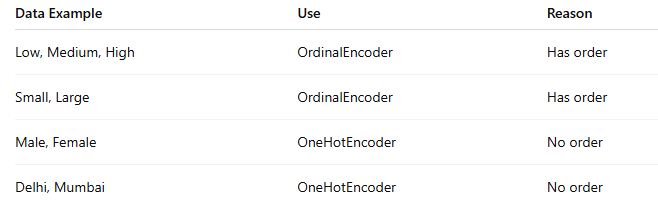

# By Columns transfer ColumnTransformer

In [72]:
transformer = ColumnTransformer(transformers=[
    ('tnf1', SimpleImputer(), ['fever']),
    ('tnf2', OrdinalEncoder(categories=[['Mild', 'Strong']]), ['cough']),
    ('tnf3', OneHotEncoder(sparse_output=False, drop='first'), ['gender', 'city'])
], remainder='passthrough')

In [73]:
transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tnf1', ...), ('tnf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [74]:
transformer.fit_transform(X_train).shape

(80, 7)

In [75]:

transformer.transform(X_test).shape

(20, 7)

| Part                      | Meaning                                    |
| ------------------------- | ------------------------------------------ |
| `'tnf1'`                  | Name of transformation (anything you want) |
| `SimpleImputer()`         | Which preprocessing to apply               |
| `['fever']`               | Column where it will apply                 |
| `'tnf2'`                  | Name of second transformation              |
| `OrdinalEncoder(...)`     | Encoder for ordered data                   |
| `['cough']`               | Column for ordinal encoding                |
| `'tnf3'`                  | Name of third transformation               |
| `OneHotEncoder(...)`      | Encoding for categorical data              |
| `['gender','city']`       | Columns for one-hot encoding               |
| `remainder='passthrough'` | Keep remaining columns unchanged           |


In [86]:
# fever → missing values filled
# cough → converted to numbers (Mild=0, Strong=1)
# gender, city → converted to multiple columns
# rest columns → unchanged

| Aspect              | OrdinalEncoder                                 | OneHotEncoder                                 | ColumnTransformer                                    |
| ------------------- | ---------------------------------------------- | --------------------------------------------- | ---------------------------------------------------- |
| Purpose             | Converts ordered categorical data into numbers | Converts categorical data into binary columns | Applies different preprocessing to different columns |
| When to use         | When categories have a natural order           | When categories have no order                 | When dataset has mixed types (numeric + categorical) |
| Output format       | Single column with numeric values              | Multiple columns with 0 and 1                 | Combined transformed dataset                         |
| Data type handled   | Ordered categorical data                       | Unordered categorical data                    | All types (numeric, categorical, missing)            |
| Risk                | Can mislead model if no real order exists      | No major risk, safe method                    | No risk, just a pipeline tool                        |
| Transformation type | Encoding                                       | Encoding                                      | Combination of multiple transformations              |


In [87]:
# OrdinalEncoder is used for ordered categories, OneHotEncoder is used for unordered categories, and ColumnTransformer is used to apply multiple
# preprocessing steps to different columns in a dataset.

In [88]:
# Example another

In [89]:
data = {
    'age': [22, 25, 30, 28, 35, 40, 23, 31, 29, 27],
    'salary': [20000, 25000, 30000, 28000, 35000, 40000, 22000, 31000, 29000, 27000],
    'fever': ['Yes', 'No', 'Yes', None, 'No', 'Yes', None, 'No', 'Yes', 'No'],
    'cough': ['Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong', 'Mild', 'Strong'],
    'gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'city': ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi', 'Chennai'],
    'smoker': ['Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes'],
    'has_covid': [1,0,1,0,0,1,0,1,0,1]
}

df = pd.DataFrame(data)

In [90]:
df

,age,salary,fever,cough,gender,city,smoker,has_covid
0,22,20000,Yes,Mild,Male,Delhi,Yes,1
1,25,25000,No,Strong,Female,Mumbai,No,0
2,30,30000,Yes,Mild,Male,Delhi,No,1
3,28,28000,None,Strong,Female,Chennai,Yes,0
4,35,35000,No,Mild,Male,Mumbai,No,0
5,40,40000,Yes,Strong,Female,Delhi,Yes,1
6,23,22000,None,Mild,Male,Chennai,No,0
7,31,31000,No,Strong,Female,Mumbai,Yes,1
8,29,29000,Yes,Mild,Male,Delhi,No,0
9,27,27000,No,Strong,Female,Chennai,Yes,1


In [91]:
X = df.drop(columns=['has_covid'])

In [92]:
X

,age,salary,fever,cough,gender,city,smoker
0,22,20000,Yes,Mild,Male,Delhi,Yes
1,25,25000,No,Strong,Female,Mumbai,No
2,30,30000,Yes,Mild,Male,Delhi,No
3,28,28000,None,Strong,Female,Chennai,Yes
4,35,35000,No,Mild,Male,Mumbai,No
5,40,40000,Yes,Strong,Female,Delhi,Yes
6,23,22000,None,Mild,Male,Chennai,No
7,31,31000,No,Strong,Female,Mumbai,Yes
8,29,29000,Yes,Mild,Male,Delhi,No
9,27,27000,No,Strong,Female,Chennai,Yes


In [93]:
y = df['has_covid']

In [94]:
y

0    1
1    0
2    1
3    0
4    0
5    1
6    0
7    1
8    0
9    1
Name: has_covid, dtype: int64

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [96]:
X_train.shape

(8, 7)

In [97]:
X_test.shape

(2, 7)

In [98]:
transformer  = ColumnTransformer(transformers=[
    ('fever_impute',SimpleImputer(strategy='most_frequent'), ['fever']),
    ('cough_ord', OrdinalEncoder(categories=[['Mild', 'Strong']]), ['cough']),
    ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['gender', 'city', 'smoker'])
  ], remainder='passthrough')
])

SyntaxError: unmatched ']' (2768771455.py, line 6)